# State-Variable Filter (SVF)

Two SVF implementations live in `src/python/filters/svf.py`:

| Implementation | Topology | Cutoff accuracy | Notes |
|---|---|---|---|
| `svf` | Chamberlin (two-integrator) | Approximate — sin pre-warp drifts at high fc/fs | Cutoff and resonance can change every sample without instability |
| `zdf_svf` | Zavalishin TPT (ZDF) | Exact — tan pre-warp matches −3 dB to `cutoff` Hz | No one-sample feedback delay; accurate to fs/2 |

Both expose the same five output modes: `'lp'`, `'bp'`, `'hp'`, `'notch'`, `'all'`.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.filters import svf, zdf_svf
from python.generators import generate_impulse, generate_white_noise, generate_sine

FS = 44100
DURATION = 4.0      # long impulse → fine frequency resolution
CUTOFF = 1000.0
BUTTERWORTH_Q = 1.0 / np.sqrt(2)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [2]:
# ── shared helpers ────────────────────────────────────────────────────────────

def impulse(duration=DURATION):
    _, imp = generate_impulse(fs=FS, duration=duration)
    return imp

def freq_db(h):
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20.0 * np.log10(np.abs(np.fft.rfft(h)) + 1e-12)
    return freqs, db

def plot_h(ax, h, label, color, cutoff=None, lw=1.2):
    freqs, db = freq_db(h)
    mask = freqs > 0
    ax.semilogx(freqs[mask], db[mask], label=label, color=color, linewidth=lw)
    if cutoff is not None:
        ax.axvline(cutoff, color='gray', linewidth=0.6, linestyle='--', alpha=0.4)

def style_freq(ax, xlim=(20, FS / 2), ylim=(-60, 15)):
    ax.set_xlabel('Frequency (Hz)', fontsize=8)
    ax.set_ylabel('Magnitude (dB)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, which='both', linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=7)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

MODE_STYLES = [
    ('lp',    'steelblue',     'LP'),
    ('bp',    'darkorange',    'BP'),
    ('hp',    'mediumseagreen','HP'),
    ('notch', 'crimson',       'Notch'),
]

## 1  Chamberlin SVF — all output modes

A single filter pass simultaneously produces LP, BP, HP, and notch (LP + HP) outputs.
The cutoff and resonance parameters are simple scalar multipliers in the loop,
so they can be updated every sample without stability concerns.

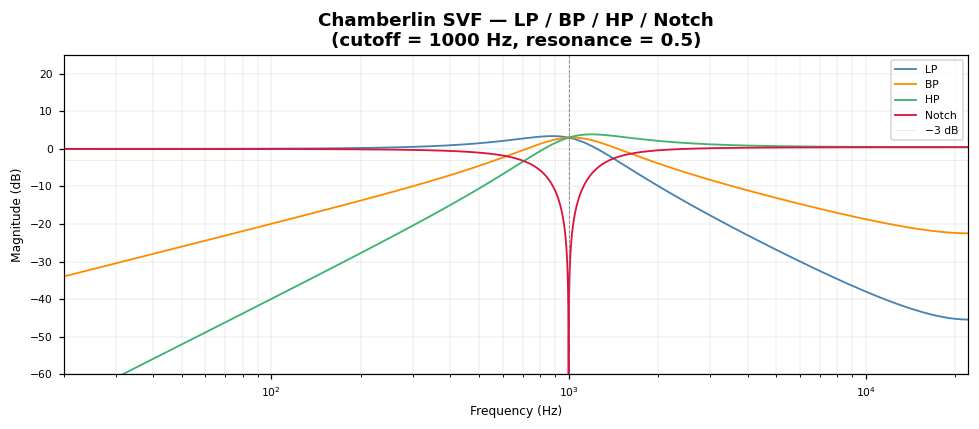

In [3]:
imp = impulse()
fig, ax = plt.subplots(figsize=(9, 4))

for mode, color, label in MODE_STYLES:
    h = svf(imp, cutoff=CUTOFF, fs=FS, resonance=0.5, mode=mode)
    plot_h(ax, h, label=label, color=color, cutoff=CUTOFF)

ax.axhline(-3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5, label='−3 dB')
ax.set_title(f'Chamberlin SVF — LP / BP / HP / Notch\n(cutoff = {int(CUTOFF)} Hz, resonance = 0.5)',
             fontweight='bold')
style_freq(ax, ylim=(-60, 25))
plt.tight_layout()
plt.show()

## 2  Chamberlin SVF — resonance sweep (LP)

`resonance` ∈ [0, 1): 0 → Butterworth (maximally flat, Q = √2); approaching 1 → self-oscillation.
The resonant peak grows with increasing resonance.

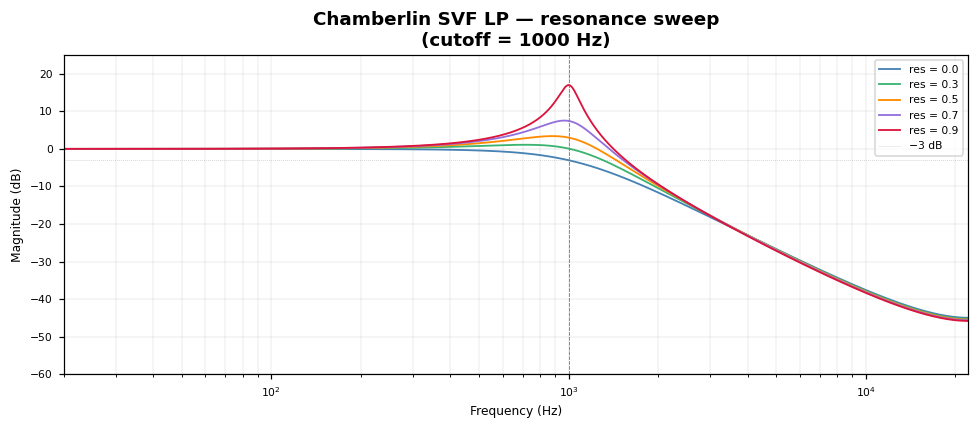

In [4]:
RESONANCES = [0.0, 0.3, 0.5, 0.7, 0.9]
RES_COLORS = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple', 'crimson']

fig, ax = plt.subplots(figsize=(9, 4))

for res, color in zip(RESONANCES, RES_COLORS):
    h = svf(imp, cutoff=CUTOFF, fs=FS, resonance=res, mode='lp')
    plot_h(ax, h, label=f'res = {res}', color=color, cutoff=CUTOFF)

ax.axhline(-3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5, label='−3 dB')
ax.set_title(f'Chamberlin SVF LP — resonance sweep\n(cutoff = {int(CUTOFF)} Hz)',
             fontweight='bold')
style_freq(ax, ylim=(-60, 25))
plt.tight_layout()
plt.show()

## 3  Chamberlin SVF — impulse response (time domain)

The three simultaneous outputs from a single impulse.
Higher resonance means slower ring-down (higher Q → lower damping).

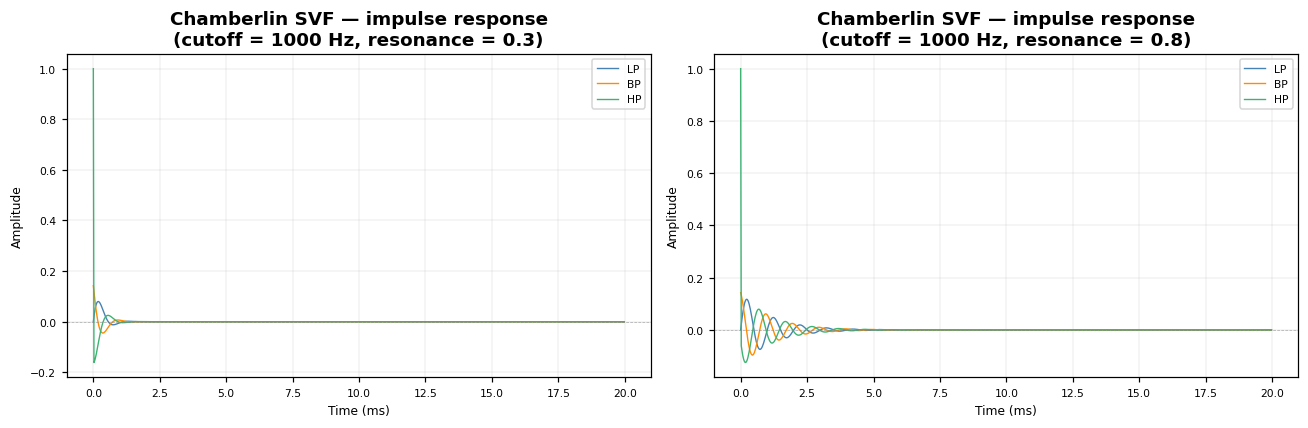

In [5]:
_, imp_short = generate_impulse(fs=FS, duration=1.0)
window_ms = 20
n_win = int(window_ms * FS / 1000)
t_ms = np.arange(n_win) / FS * 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for res, ax, title in [(0.3, axes[0], 'resonance = 0.3'), (0.8, axes[1], 'resonance = 0.8')]:
    lp, bp, hp = svf(imp_short, cutoff=CUTOFF, fs=FS, resonance=res, mode='all')
    ax.plot(t_ms, lp[:n_win], label='LP', color='steelblue',       linewidth=0.9)
    ax.plot(t_ms, bp[:n_win], label='BP', color='darkorange',      linewidth=0.9)
    ax.plot(t_ms, hp[:n_win], label='HP', color='mediumseagreen',  linewidth=0.9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
    ax.set_title(f'Chamberlin SVF — impulse response\n(cutoff = {int(CUTOFF)} Hz, {title})',
                 fontweight='bold')
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4  Chamberlin SVF — per-sample cutoff modulation

Because `f` (the cutoff coefficient) is just a scalar multiplier, it can be updated on every sample.
Here a 2 Hz LFO sweeps the cutoff from 200 Hz to 1100 Hz over white noise.

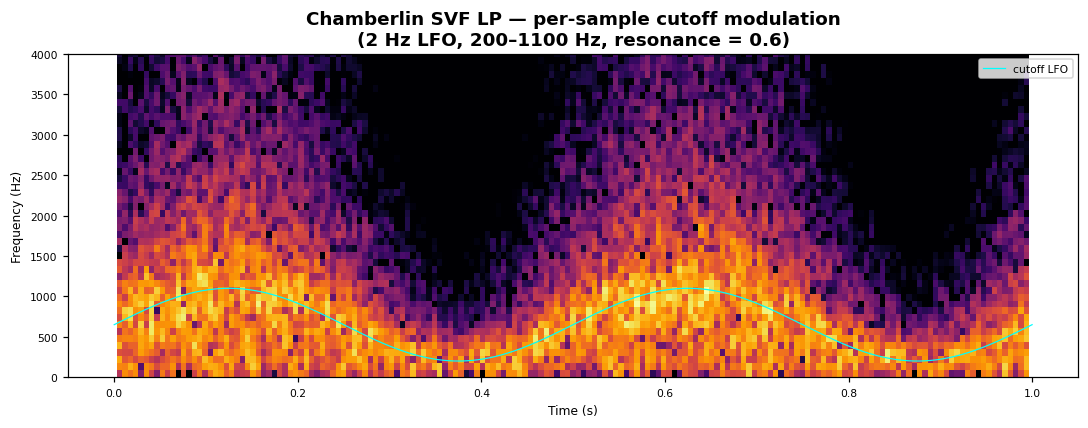

In [6]:
_, noise = generate_white_noise(fs=FS, duration=1.0)
t = np.arange(len(noise)) / FS

lfo_rate = 2.0
cutoff_mod = 200.0 + 900.0 * (0.5 + 0.5 * np.sin(2.0 * np.pi * lfo_rate * t))

lp_mod = np.empty(len(noise))
bp_s = lp_s = 0.0
res = 0.6
for i, x in enumerate(noise):
    fc = cutoff_mod[i]
    q = np.sqrt(2.0) * (1.0 - res)
    f_max = np.sqrt(q * q + 4.0) - q
    f = min(2.0 * np.sin(np.pi * fc / FS), f_max * (1.0 - 1e-9))
    lp_s = lp_s + f * bp_s
    hp_s = x - lp_s - q * bp_s
    bp_s = f * hp_s + bp_s
    lp_mod[i] = lp_s

fig, ax = plt.subplots(figsize=(10, 4))
ax.specgram(lp_mod, NFFT=512, Fs=FS, noverlap=256, cmap='inferno', vmin=-80)
ax.plot(t, cutoff_mod, color='cyan', linewidth=0.8, label='cutoff LFO')
ax.set_title('Chamberlin SVF LP — per-sample cutoff modulation\n'
             '(2 Hz LFO, 200–1100 Hz, resonance = 0.6)', fontweight='bold')
ax.set_xlabel('Time (s)', fontsize=8)
ax.set_ylabel('Frequency (Hz)', fontsize=8)
ax.tick_params(labelsize=7)
ax.set_ylim(0, 4000)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5  ZDF SVF — all output modes

The ZDF (Zavalishin TPT) implementation uses bilinear (trapezoidal) integrators.
`resonance` here is the Q factor: `1/√2` ≈ 0.707 → Butterworth (default).
The tan pre-warp ensures the −3 dB point is exactly `cutoff` Hz at any fc/fs ratio.

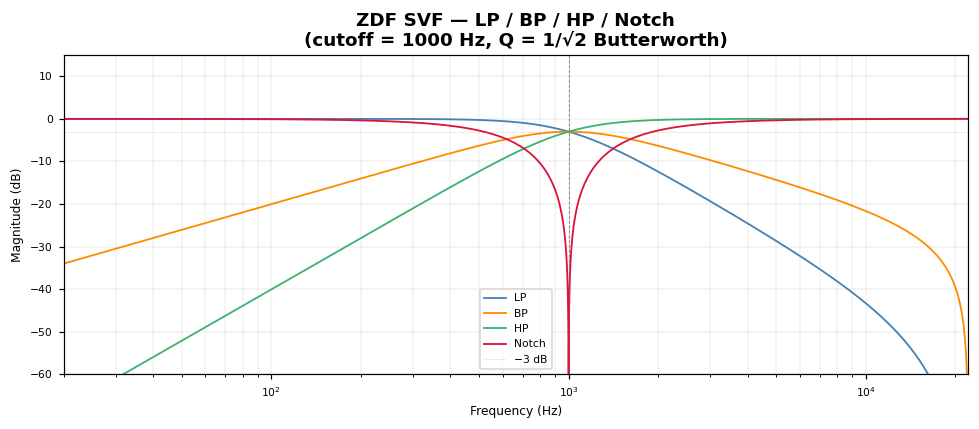

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

for mode, color, label in MODE_STYLES:
    h = zdf_svf(imp, cutoff=CUTOFF, fs=FS, resonance=BUTTERWORTH_Q, mode=mode)
    plot_h(ax, h, label=label, color=color, cutoff=CUTOFF)

ax.axhline(-3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5, label='−3 dB')
ax.set_title(f'ZDF SVF — LP / BP / HP / Notch\n'
             f'(cutoff = {int(CUTOFF)} Hz, Q = 1/√2 Butterworth)', fontweight='bold')
style_freq(ax, ylim=(-60, 15))
plt.tight_layout()
plt.show()

## 6  ZDF SVF — Q sweep (LP)

Q = 1/√2 → Butterworth; higher Q → resonant peak; Q → ∞ → self-oscillation.
Unlike the Chamberlin `resonance` parameter, Q has a direct physical interpretation.

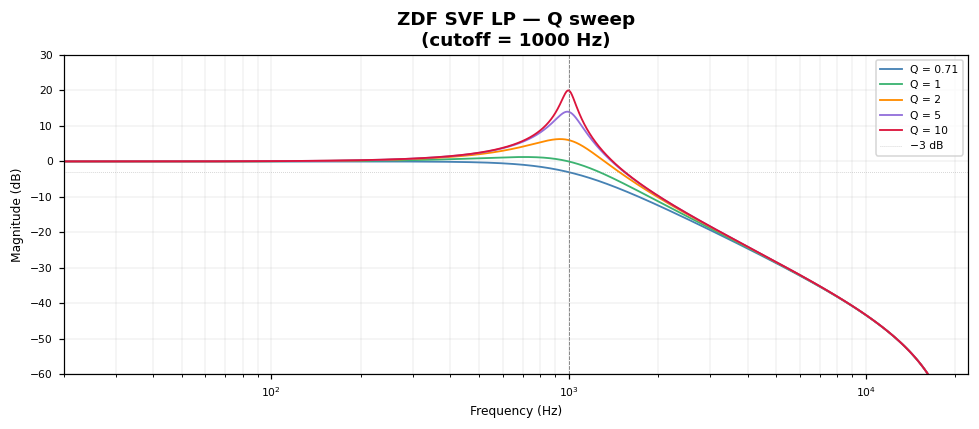

In [8]:
Q_VALUES = [BUTTERWORTH_Q, 1.0, 2.0, 5.0, 10.0]
Q_COLORS = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple', 'crimson']

fig, ax = plt.subplots(figsize=(9, 4))

for Q, color in zip(Q_VALUES, Q_COLORS):
    h = zdf_svf(imp, cutoff=CUTOFF, fs=FS, resonance=Q, mode='lp')
    plot_h(ax, h, label=f'Q = {Q:.2g}', color=color, cutoff=CUTOFF)

ax.axhline(-3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5, label='−3 dB')
ax.set_title(f'ZDF SVF LP — Q sweep\n(cutoff = {int(CUTOFF)} Hz)', fontweight='bold')
style_freq(ax, ylim=(-60, 30))
plt.tight_layout()
plt.show()

## 7  ZDF vs Chamberlin — accuracy at high fc/fs

At low cutoff-to-sample-rate ratios both implementations agree well.
At fc/fs = 0.4 (17 640 Hz at 44.1 kHz) the Chamberlin sin pre-warp introduces
a measurable frequency error; the ZDF tan pre-warp hits −3 dB exactly.

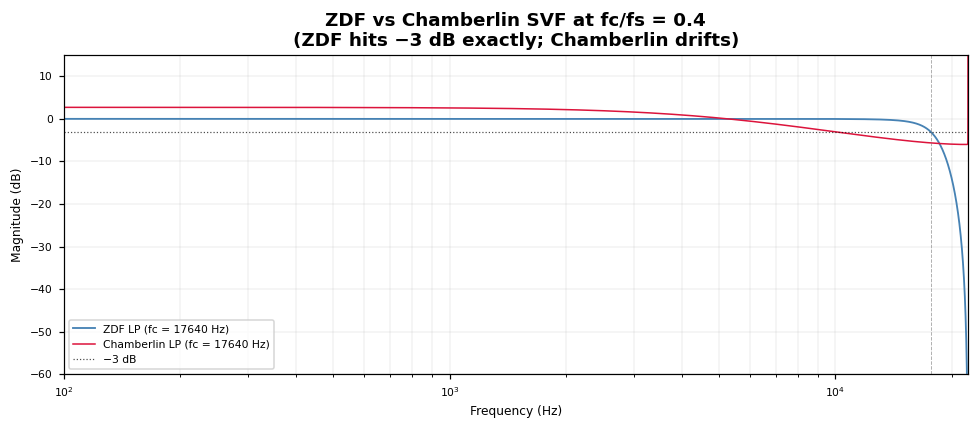

In [9]:
HIGH_FC = 0.4 * FS   # 17640 Hz

lp_zdf  = zdf_svf(imp, cutoff=HIGH_FC, fs=FS, resonance=BUTTERWORTH_Q, mode='lp')
lp_cham = svf(imp,     cutoff=HIGH_FC, fs=FS, resonance=0.0,           mode='lp')

fig, ax = plt.subplots(figsize=(9, 4))
plot_h(ax, lp_zdf,  label=f'ZDF LP (fc = {int(HIGH_FC)} Hz)',        color='steelblue', cutoff=HIGH_FC)
plot_h(ax, lp_cham, label=f'Chamberlin LP (fc = {int(HIGH_FC)} Hz)', color='crimson',   cutoff=HIGH_FC, lw=1.0)
ax.axhline(-3, color='black', linewidth=0.8, linestyle=':', alpha=0.7, label='−3 dB')
ax.set_title('ZDF vs Chamberlin SVF at fc/fs = 0.4\n'
             '(ZDF hits −3 dB exactly; Chamberlin drifts)', fontweight='bold')
style_freq(ax, xlim=(100, FS / 2), ylim=(-60, 15))
plt.tight_layout()
plt.show()

## 8  ZDF SVF — KVL identity: LP + k·BP + HP = input

Kirchhoff's voltage law applied to the TPT topology predicts that
`LP + (1/Q)·BP + HP` reconstructs the input exactly at every sample.
The error column below should be at floating-point precision (~10⁻¹⁵).

Max reconstruction error: 1.11e-16   (expected ~floating-point precision)


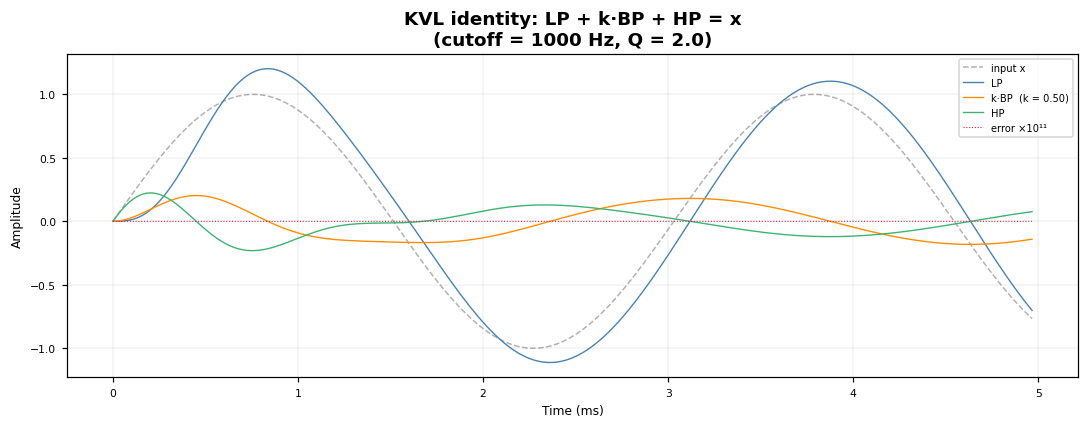

In [10]:
_, sig = generate_sine(freq=330.0, fs=FS, duration=0.005)
t_ms = np.arange(len(sig)) / FS * 1000

Q = 2.0
k = 1.0 / Q
lp, bp, hp = zdf_svf(sig, cutoff=CUTOFF, fs=FS, resonance=Q, mode='all')
reconstructed = lp + k * bp + hp
error = reconstructed - sig

print(f'Max reconstruction error: {np.max(np.abs(error)):.2e}   '
      f'(expected ~floating-point precision)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_ms, sig,          label='input x',              color='gray',          linewidth=1.0, linestyle='--', alpha=0.6)
ax.plot(t_ms, lp,           label='LP',                   color='steelblue',     linewidth=0.9)
ax.plot(t_ms, k * bp,       label=f'k·BP  (k = {k:.2f})', color='darkorange',   linewidth=0.9)
ax.plot(t_ms, hp,           label='HP',                   color='mediumseagreen',linewidth=0.9)
ax.plot(t_ms, error * 1e11, label='error ×10¹¹',         color='crimson',       linewidth=0.7, linestyle=':')
ax.set_title(f'KVL identity: LP + k·BP + HP = x\n(cutoff = {int(CUTOFF)} Hz, Q = {Q})',
             fontweight='bold')
ax.set_xlabel('Time (ms)', fontsize=8)
ax.set_ylabel('Amplitude', fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.legend(fontsize=6.5)
plt.tight_layout()
plt.show()

## 9  Cutoff frequency sweep — frequency response grid

LP frequency response across a decade of cutoff frequencies (200 Hz → 8 kHz)
shows how the filter tracks cutoff correctly at various fc/fs ratios.
Each curve's −3 dB point should fall exactly on its vertical marker.

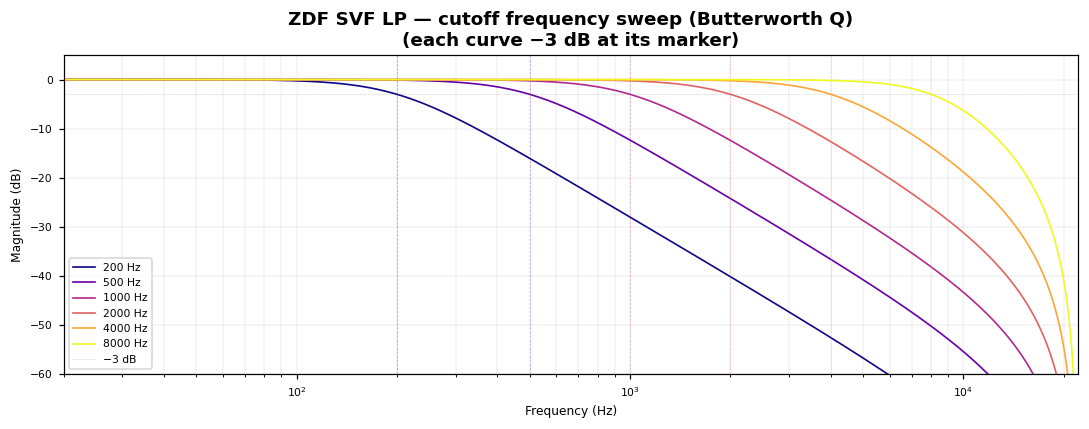

In [11]:
CUTOFFS = [200, 500, 1000, 2000, 4000, 8000]
cmap = plt.cm.plasma
colors = [cmap(i / (len(CUTOFFS) - 1)) for i in range(len(CUTOFFS))]

fig, ax = plt.subplots(figsize=(10, 4))

for fc, color in zip(CUTOFFS, colors):
    h = zdf_svf(imp, cutoff=fc, fs=FS, resonance=BUTTERWORTH_Q, mode='lp')
    freqs, db = freq_db(h)
    mask = freqs > 0
    ax.semilogx(freqs[mask], db[mask], color=color, linewidth=1.1, label=f'{fc} Hz')
    ax.axvline(fc, color=color, linewidth=0.5, linestyle='--', alpha=0.35)

ax.axhline(-3, color='gray', linewidth=0.5, linestyle=':', alpha=0.5, label='−3 dB')
ax.set_title('ZDF SVF LP — cutoff frequency sweep (Butterworth Q)\n'
             '(each curve −3 dB at its marker)', fontweight='bold')
style_freq(ax, ylim=(-60, 5))
plt.tight_layout()
plt.show()

## Audio Examples

The SVF simultaneously outputs LP, BP, and HP from a single filter pass. A sawtooth at 220 Hz with cutoff=1000 Hz and resonance=0.6 shows how one filter topology covers all three EQ shapes at once.


In [ ]:
from IPython.display import Audio, display

DUR_A  = 2.0
N_A    = int(FS * DUR_A)
t_a    = np.arange(N_A) / FS
saw_a  = 0.4 * (2 * ((220.0 * t_a) % 1.0) - 1.0)
FC_A   = 1000.0
RES_A  = 0.6

lp_a, bp_a, hp_a = svf(saw_a, cutoff=FC_A, fs=FS, resonance=RES_A, mode="all")

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Dry sawtooth at 220 Hz")
display(Audio(norm(saw_a), rate=FS))
print(f"SVF lowpass at {int(FC_A)} Hz — warm, dark")
display(Audio(norm(lp_a), rate=FS))
print(f"SVF bandpass at {int(FC_A)} Hz — resonant peak only, nasal")
display(Audio(norm(bp_a), rate=FS))
print(f"SVF highpass at {int(FC_A)} Hz — thin, bright")
display(Audio(norm(hp_a), rate=FS))